In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, KBinsDiscretizer
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print(f" {df} Columns ")
print(list(df.columns))


      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6   Overweight   
1               

In [3]:
print(f"{len(df)} ")

rows, columns = df.shape
print(f"Το dataset έχει {rows} γραμμές και {columns} στήλες.")

374 
Το dataset έχει 374 γραμμές και 13 στήλες.


In [4]:
pd.set_option('display.max_columns', None)
display(df.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## ΚΑΘΑΡΙΣΜΟΣ ΔΕΔΟΜΕΝΩΝ

Αρχικά, θα διαχωρίσω την πίεση του αίματος σε συστολική και διαστολική χωρίζοντας τη στήλη Blood Pressure σε 2 στήλες:

In [5]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic'] = pd.to_numeric(df['Systolic'])
df['Diastolic'] = pd.to_numeric(df['Diastolic'])

df = df.drop('Blood Pressure', axis=1)
display(df.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [6]:
print(df['BMI Category'].unique())
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
display(df.head())

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


Παρατηρώντας τα Δεδομένα οι στήλες Gender Occupation BMICategory SleepDisorder είναι ποιοτικές μεταβλητές
Ενώ οι Age SleepDuration QualityofSleep PhysicalActivityLevel StressLevel HeartRate DailySteps Systolic Diastolic είναι ποσοτικές.

Οι αλγόριθμοι καταλαβαίνουν μόνο αριθμούς και αποστάσεις. Άρα πρέπει να μετατρέψουμε τις ποιοτικές μεταβλημτές σε ποσοτικές.

In [7]:
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df.head())

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,Gender_Male,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,6,42,6,77,4200,NaN,126,83,True,False,False,False,False,False,False,False,False,True,False,False,True
1,2,28,6.2,6,60,8,75,10000,NaN,125,80,True,True,False,False,False,False,False,False,False,False,False,False,False
2,3,28,6.2,6,60,8,75,10000,NaN,125,80,True,True,False,False,False,False,False,False,False,False,False,False,False
3,4,28,5.9,4,30,8,85,3000,Sleep Apnea,140,90,True,False,False,False,False,False,True,False,False,False,False,True,False
4,5,28,5.9,4,30,8,85,3000,Sleep Apnea,140,90,True,False,False,False,False,False,True,False,False,False,False,True,False


In [8]:
print("Κενές τιμές ανά στήλη:")
print(df.isnull().sum())

duplicates_count = df.duplicated().sum()
print(f"Συνολικές διπλότυπες γραμμές στο dataset: {duplicates_count}")

Κενές τιμές ανά στήλη:
Person ID                            0
Age                                  0
Sleep Duration                       0
Quality of Sleep                     0
Physical Activity Level              0
Stress Level                         0
Heart Rate                           0
Daily Steps                          0
Sleep Disorder                     219
Systolic                             0
Diastolic                            0
Gender_Male                          0
Occupation_Doctor                    0
Occupation_Engineer                  0
Occupation_Lawyer                    0
Occupation_Manager                   0
Occupation_Nurse                     0
Occupation_Sales Representative      0
Occupation_Salesperson               0
Occupation_Scientist                 0
Occupation_Software Engineer         0
Occupation_Teacher                   0
BMI Category_Obese                   0
BMI Category_Overweight              0
dtype: int64
Συνολικές διπλότυπες γραμμές

In [9]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("Κατανομή των κατηγοριών διαταραχής ύπνου:")
print(df['Sleep Disorder'].value_counts())

Κατανομή των κατηγοριών διαταραχής ύπνου:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


## 'Ελεγχος για ακραίες τιμές

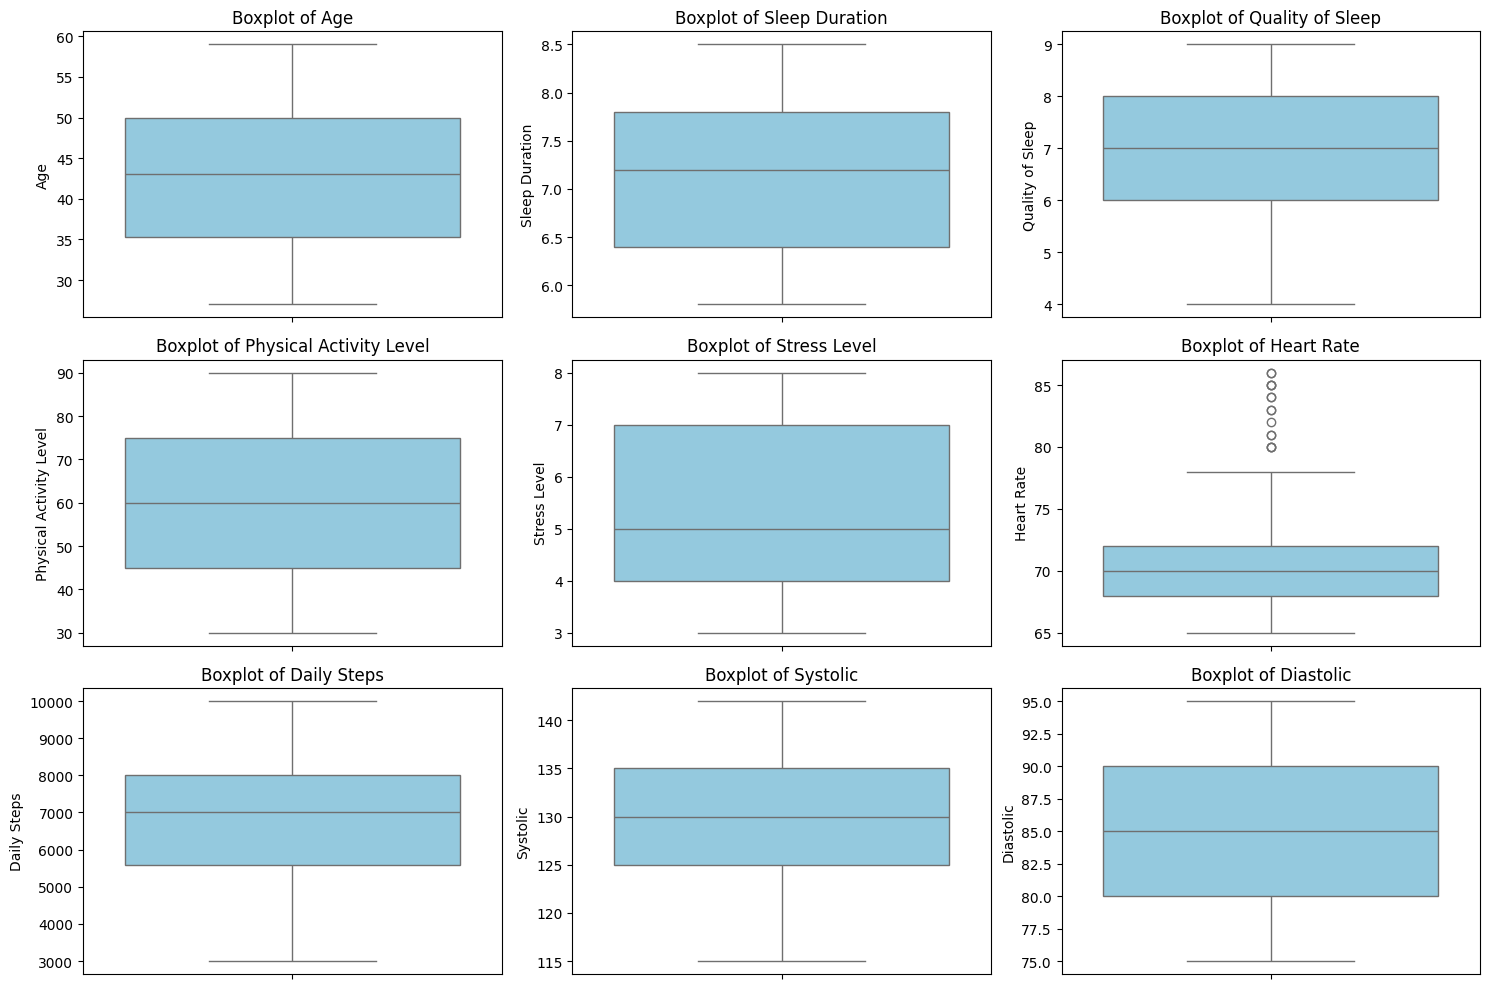

In [10]:
numeric_columns_to_check = ['Age', 'Sleep Duration', 'Quality of Sleep', 
                            'Physical Activity Level', 'Stress Level', 
                            'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

#boxplot
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns_to_check, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Για τον εντοπισμό πιθανών ακραίων τιμών (outliers) στο σύνολο δεδομένων, δημιουργήθηκαν θηκογράμματα (boxplots) για όλες τις συνεχείς αριθμητικές μεταβλητές.

**Παρατηρήσεις και Ανάλυση:**
*  Όπως φαίνεται στα διαγράμματα, οι μεταβλητές `Age`, `Sleep Duration`, `Quality of Sleep`, `Physical Activity Level`, `Stress Level`, `Daily Steps`, `Systolic` και `Diastolic` παρουσιάζουν μια εξαιρετικά ομαλή κατανομή. Δεν παρατηρείται καμία τιμή εκτός των ορίων, που δείχνει υψηλή ποιότητα δεδομένων χωρίς σφάλματα καταχώρησης.
*  Η μοναδική μεταβλητή που παρουσιάζει ακραίες τιμές είναι ο Καρδιακός Ρυθμός (`Heart Rate`), όπου εντοπίζεται μια ομάδα ατόμων με παλμούς ηρεμίας άνω των 80 bpm.

**Απόφαση Διαχείρισης:**
Αποφασίστηκε η **διατήρηση** αυτών των ακραίων τιμών στο σύνολο δεδομένων χωρίς καμία τροποποίηση ή διαγραφή. Δεδομένου ότι αναλύουμε ιατρικά δεδομένα, η ταχυκαρδία δεν αποτελεί θόρυβο ή λάθος. Η αφαίρεσή τους θα στερούσε από τα μοντέλα ταξινόμησης πολύτιμη πληροφορία, μειώνοντας την ακρίβεια.

In [12]:
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

#Κανονικοποίηση
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train-Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "k-Nearest Neighbors (kNN)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    #Εκπαίδευση 
    model.fit(X_train_resampled, y_train_resampled)
    
    #Πρόβλεψη
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f" {name} ")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print("-" * 55 + "\n")

for name, acc in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {acc*100:.2f}%")

 Decision Tree 
Accuracy: 0.8933

              precision    recall  f1-score   support

    Insomnia       0.72      0.87      0.79        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.86      0.75      0.80        16

    accuracy                           0.89        75
   macro avg       0.85      0.86      0.85        75
weighted avg       0.90      0.89      0.89        75

-------------------------------------------------------

 k-Nearest Neighbors (kNN) 
Accuracy: 0.9067

              precision    recall  f1-score   support

    Insomnia       0.80      0.80      0.80        15
        None       1.00      0.91      0.95        44
 Sleep Apnea       0.80      1.00      0.89        16

    accuracy                           0.91        75
   macro avg       0.87      0.90      0.88        75
weighted avg       0.92      0.91      0.91        75

-------------------------------------------------------

 Naive Bayes 
Accuracy: 0.9200

            